In [366]:
#####################################bayes_opt库实现贝叶斯优化，基于高斯，且只能用高斯过程，自定义采集函数（poi、ei、ucb）##########
############去除重复行有单独的代码，命名为：删除重复行（第六篇）#################################
import pandas as pd
import csv
import os
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization
import numpy as np
from bayes_opt import util
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

output_dir_path = r'D:\桌面文件\第六篇文章\output'
if not os.path.exists(output_dir_path):
   os.makedirs(output_dir_path)

def objective(C, gamma):
# 加载数据集
    dataset = pd.read_excel(r"E:\论文5\a\特征优化 CV\0630\UAV0630.xlsx")
    dataset.head()
    # 准备数据
    X, y = dataset.iloc[:,:-1], dataset.iloc[:,-1] 

# 归一化特征数据
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

# 定义XGBoost回归器
    model = SVR(kernel='rbf', C=int(C), gamma=int(gamma))
 
# 计算交叉验证得分的负值
    cv_score = -cross_val_score(model, X_scaled, y, cv=5, scoring='neg_root_mean_squared_error').mean()

# 保存当前trial的结果
    output_file_path = os.path.join(output_dir_path, f'trial_{len(os.listdir(output_dir_path))+1}.csv')
    with open(output_file_path, 'w', newline='', encoding='utf-8') as f:
        
        writer = csv.writer(f)
        writer.writerow(['params', 'value'])
      #  writer.writerow([{'C': int(C), 'gamma': int(gamma), cv_score}])
        writer.writerow([{'C': int(C), 'gamma': int(gamma), 'cv_score': cv_score}])

        return cv_score

pbounds = {'C': (1, 100), 'gamma': (0.001, 1)}
optimizer = BayesianOptimization(
    f=objective,
    pbounds=pbounds,
    verbose=2,
    random_state=81,
)

optimizer.set_gp_params(normalize_y=True)#设置高斯过程
acq_func = util.UtilityFunction(kind='poi', kappa=2.576, xi=0.0)#设置采集函数（ei、poi、ucb）
optimizer.maximize(n_iter=10, acquisition_function=acq_func)#设置迭代次数

rows = []
for i, result in enumerate(optimizer.res):  
    output_file_path = os.path.join(output_dir_path, f'trial_{i+1}.csv') 
    with open(output_file_path, 'r', encoding='utf-8') as f:
         reader = csv.reader(f)
         next(reader)  # 跳过表头
         row = [i+1, result['target'], result['params']['C'], result['params']['gamma']]
         rows.append(row)
df = pd.DataFrame(rows, columns=['trial_number', 'value', 'C', 'gamma'])
df.drop_duplicates(subset=['value'], keep='first', inplace=True)
df.to_excel(r"E:\text\测试.xlsx", index=False)
best_params = optimizer.max['params']
best_value = optimizer.max['target']

print(f"Best params: {best_params}")
print(f"Best value: {best_value}")

|   iter    |  target   |     C     |   gamma   |
-------------------------------------------------
| 1         | 0.08871   | 36.19     | 0.3415    |
| 2         | 0.08871   | 93.38     | 0.9139    |
| 3         | 0.08871   | 83.91     | 0.06043   |
| 4         | 0.08871   | 25.57     | 0.5096    |
| 5         | 0.08871   | 9.865     | 0.7854    |
| 6         | 0.08871   | 70.1      | 0.8538    |
| 7         | 0.08871   | 3.956     | 0.1314    |
| 8         | 0.08871   | 50.18     | 0.2707    |
| 9         | 0.08871   | 48.39     | 0.5245    |
| 10        | 0.08871   | 57.59     | 0.89      |
| 11        | 0.08871   | 19.43     | 0.241     |
| 12        | 0.08871   | 77.24     | 0.5945    |
| 13        | 0.08871   | 84.59     | 0.1041    |
| 14        | 0.08871   | 15.91     | 0.2132    |
| 15        | 0.08871   | 14.89     | 0.6262    |
Best params: {'C': 36.186492662718415, 'gamma': 0.34150802781261236}
Best value: 0.08871308889557696


IPVI     0
OSAVI    0
SAVI     0
CGMI     0
dtype: int64
IPVI     0
OSAVI    0
SAVI     0
CGMI     0
dtype: int64
TMSE: 0.0169522762713912
TRMSE: 0.13020090733705045
TMAE: 0.10664778553676832
TMAPE: 20.40591846873473
TR²: 0.3178697781248926
TRMSRE: 0.27043990064413836
VMSE: 0.017475287768445855
VRMSE: 0.13219412909976697
VMAE: 0.1045151350554859
VMAPE: 23.682718092142522
VR²: 0.41346772844152013
VRMSRE: 0.35558086772441416


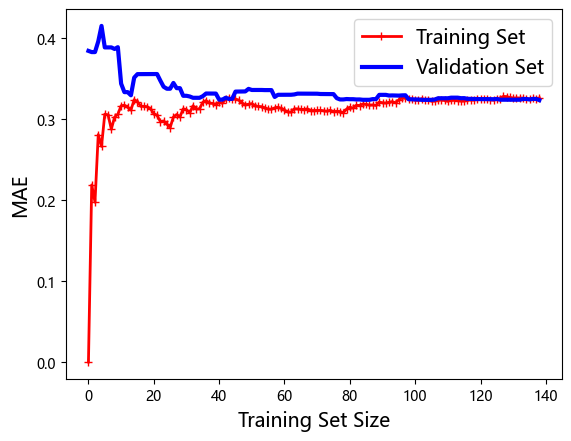

      y_train    y_pred
167  0.680371  0.657278
106  0.331868  0.539203
17   0.569196  0.620626
118  0.460436  0.533946
52   0.798984  0.611951
128  0.348272  0.411792
174  0.783125  0.619483
108  0.617563  0.550497
107  0.646002  0.607549
18   0.563907  0.625523
7    0.477316  0.514836
179  0.638312  0.618841
160  0.839886  0.789464
130  0.624231  0.486234
54   0.467888  0.468851
140  0.833982  0.607357
148  0.675519  0.626509
53   0.487408  0.601598
104  0.656407  0.600255
156  0.747512  0.509079
68   0.511012  0.614336
152  0.855002  0.773314
113  0.785928  0.558815
0    0.588962  0.589536
109  0.718412  0.580825
103  0.825791  0.824795
111  0.596182  0.554005
157  0.617779  0.546444
134  0.565922  0.505962
89   0.558048  0.482687
82   0.407934  0.517746
19   0.640398  0.668028
8    0.545287  0.485809
48   0.311073  0.459009
158  0.320245  0.482572
26   0.541610  0.558905
93   0.404129  0.419916
13   0.424734  0.370317
165  0.868667  0.844586
84   0.387027  0.627317
117  0.316369  0

In [573]:
import time
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
from sklearn.datasets import make_classification
import matplotlib #主要用来作图 
import matplotlib.pyplot as plt ##主要用来作图
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

matplotlib.rc("font", family='Microsoft YaHei') #使得图像中可以显示中文，字体微软雅黑
dataset=pd.read_excel(r"E:\论文5\a\特征优化 CV\0610\UAV0610.xlsx",na_values=['NA', '?', -999])
#dataset = dataset.astype(float)
dataset.head()
print(dataset.isnull().sum())  # 检查空值
print(dataset.isin([np.nan, np.inf, -np.inf]).sum())  # 检查NaN和Inf

X_1,y=dataset.iloc[:,:-1],dataset.iloc[
:,-1]#可以表示x为除了最后一列，y为最后一列
# 归一化特征数据
scaler = StandardScaler()
X = scaler.fit_transform(X_1)
#print(X,y)#输出表示x，y
#print("X维度", X.shape)
#print("y维度",y.shape)

import pandas as pd
import numpy as np
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import time
#划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=66
                                                    
                                                    
                                                    #6 17 27 29 42 63 99
                                                    , shuffle=True)#32 31




#SVR回归模型
model = SVR(kernel='rbf', C=5, gamma=0.2)
#0.001538




#五折交叉验证
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

#训练模型
model.fit(X_train, y_train)

#预测结果
y_pred = model.predict(X_train)
y_pred2 = model.predict(X_test)

# 计算评估指标-all特征
mse1 = mean_squared_error(y_train, y_pred)
rmse1 = np.sqrt(mse1)
mae1 = mean_absolute_error(y_train, y_pred)
mape1 = np.mean(np.abs((y_train - y_pred) / y_train)) * 100
r21 = r2_score(y_train, y_pred)
RMSRE1 = np.sqrt(np.mean(((y_train - y_pred) / y_train) ** 2))  
mse2 = mean_squared_error(y_test, y_pred2)
rmse2 = np.sqrt(mse2)
mae2 = mean_absolute_error(y_test, y_pred2)
mape2 = np.mean(np.abs((y_test - y_pred2) / y_test)) * 100
r22 = r2_score(y_test, y_pred2)
RMSRE2 = np.sqrt(np.mean(((y_test - y_pred2) / y_test) ** 2))  

print('TMSE:', mse1)
print('TRMSE:', rmse1)
print('TMAE:', mae1)
print('TMAPE:', mape1)
print('TR²:', r21)
print('TRMSRE:', RMSRE1)

print('VMSE:', mse2)
print('VRMSE:', rmse2)
print('VMAE:', mae2)
print('VMAPE:', mape2)
print('VR²:', r22)
print('VRMSRE:', RMSRE2)
#绘制MAE损失曲线
train_errors, val_errors = [], []
for m in range(1, len(X_train)):
    model.fit(X_train[:m], y_train[:m])
    y_train_pred = model.predict(X_train[:m])
    y_val_pred = model.predict(X_test)
    train_errors.append(mean_absolute_error(y_train[:m], y_train_pred))
    val_errors.append(mean_absolute_error(y_test, y_val_pred))
plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="Training Set")
plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Validation Set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Training Set Size", fontsize=14)
plt.ylabel("MAE", fontsize=14)
plt.show()

#图形数据输出到指定文件
import pandas as pd

# 创建一个DataFrame对象
output_df = pd.DataFrame({'Training Set Size': range(1, len(X_train)),
                          'Training MAE': np.sqrt(train_errors),
                          'Validation MAE': np.sqrt(val_errors)})#  -all特征
# 将DataFrame写入Excel文件中的第一个工作表
with pd.ExcelWriter(r"E:\论文4\产量\训练集与测试集\0630\SVR00000.xlsx") as writer:
    output_df.to_excel(writer, sheet_name='Sheet1', index=False)
##
# 输出测试集预测值和真实值，并保存到Excel文件中
df = pd.DataFrame({'y_test': y_train, 'y_pred': y_pred})
with pd.ExcelWriter(r"E:\论文5\a\特征优化 CV\0610\SVR预测与验证值.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet1', index=False)

df = pd.DataFrame({'y_train': y_test, 'y_pred': y_pred2})
with pd.ExcelWriter(r"E:\论文5\a\特征优化 CV\0610\SVR预测与训练值.xlsx") as writer:
    df.to_excel(writer, sheet_name='Sheet2', index=False)
##
   #writer.save()
print(df)